# EDA — `dataset/textos`

Análisis exploratorio de los PDFs clínicos que alimentan el RAG del agente postoperatorio.

Cada bloque de resultados va seguido de una celda de **interpretación automática** basada en los datos cargados.


In [1]:
from __future__ import annotations

import re
import sys
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pymupdf

ROOT = Path.cwd().resolve()
if not (ROOT / "core").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from core.config import get_settings  # noqa: E402
from core.scenarios import SCENARIO_OPTIONS  # noqa: E402
from knowledge.text_utils import compute_content_hash, normalize_text  # noqa: E402

settings = get_settings()
TEXTOS_DIR = (ROOT / settings.textos_dir).resolve()
MIN_DOCUMENT_CHARS = settings.min_document_chars

print(f"Proyecto: {ROOT}")
print(f"Dataset:  {TEXTOS_DIR}")
print(f"Tokenizer embedding: {settings.embedding_model}")

Proyecto: /Users/paula.zuluaga/Documents/tech-sphere/2026/postop-voice-agent
Dataset:  /Users/paula.zuluaga/Documents/tech-sphere/2026/postop-voice-agent/dataset/textos
Tokenizer embedding: ibm-granite/granite-embedding-97m-multilingual-r2


## Configuración de escenarios y keywords


In [ ]:
TOPIC_KEYWORDS: dict[str, tuple[str, ...]] = {
    "appendicitis": (
        "appendicitis",
        "apendicitis",
        "apendicectom",
        "appendectom",
        "apendice",
        "appendix",
    ),
    "cholecystitis": (
        "colecistitis",
        "cholecystitis",
        "colecistectom",
        "cholecystectom",
        "vesicula",
        "vesícula",
        "colelitiasis",
        "gallbladder",
        "biliar",
    ),
    "cervical_cancer": (
        "cuello uterino",
        "cervical",
        "cervix",
        "cérvix",
        "uterino",
        "histerectom",
    ),
    "colorectal_cancer": (
        "colorrectal",
        "colorectal",
        "colon",
        "recto",
        "colectom",
        "bowel surgery",
        "intestino",
    ),
    "total_joint_replacement": (
        "artroplast",
        "arthroplast",
        "rodilla",
        "cadera",
        "knee",
        "hip",
        "joint replacement",
        "reemplazo",
        "prótesis",
        "protesis",
    ),
    "other": (
        "cuidado estandarizado",
        "gastrointestinal",
        "funcion gastrointestinal",
        "general care",
        "nursing review",
    ),
}

FOLDER_TO_TOPIC: dict[str, str] = {
    "Appendicitis": "appendicitis",
    "cholecystitis": "cholecystitis",
    "breast_cancer": "cervical_cancer",
    "colorectal cancer": "colorectal_cancer",
    "total joint replacement": "total_joint_replacement",
    "Otro": "other",
}

EXPECTED_LABELS = {opt.value: label for _, label, opt in SCENARIO_OPTIONS}
EXPECTED_LABELS["other"] = "Otro (sin categoría)"
print("Escenarios:", EXPECTED_LABELS)

Escenarios: {'appendicitis': 'Apendicitis', 'cholecystitis': 'Colecistitis', 'cervical_cancer': 'Cáncer de cuello uterino', 'colorectal_cancer': 'Cáncer colorrectal', 'total_joint_replacement': 'Reemplazo articular', 'other': 'Otro (sin categoría)'}


In [4]:
JUNK_PATTERNS: tuple[re.Pattern[str], ...] = (
    re.compile(r"cid:\d+", re.I),
    re.compile(r"\bdoi:\s*\S+", re.I),
    re.compile(r"https?://\S+", re.I),
    re.compile(r"\ufffd"),
    re.compile(r"(?:\.{3,}|_{3,}|-{3,})"),
    re.compile(r"\b(?:vol\.?|pp\.?|issn|isbn)\b", re.I),
)


@dataclass
class DocumentStats:
    file_path: Path
    folder: str
    file_name: str
    total_pages: int
    pages_with_text: int
    empty_pages: int
    scanned_pages: int
    char_count: int
    token_count: int
    language: str
    detected_topic: str
    topic_score: int
    expected_topic: str
    likely_misclassified: bool
    folder_name_legacy: bool
    below_min_chars: bool
    excerpt: str
    alpha_ratio: float
    short_token_ratio: float
    junk_pattern_hits: int
    repeated_char_runs: int
    junk_score: float
    content_hash: str


def _detect_language(text: str) -> str:
    sample = text[:4000].lower()
    es = sum(sample.count(m) for m in (" de ", " la ", " el ", " paciente ", " dolor "))
    en = sum(sample.count(m) for m in (" the ", " and ", " patient ", " surgery "))
    if es == en:
        return "es" if re.search(r"[áéíóúñ]", sample) else "en"
    return "es" if es > en else "en"


def _score_topics(text: str) -> tuple[str, int]:
    lowered = normalize_text(text).lower()
    scores = {
        topic: sum(lowered.count(kw) for kw in keywords)
        for topic, keywords in TOPIC_KEYWORDS.items()
    }
    best_topic = max(scores, key=scores.get)
    best_score = scores[best_topic]
    if best_score == 0:
        return "other", 0
    return best_topic, best_score


def _junk_metrics(text: str) -> tuple[float, float, int, int, float]:
    if not text:
        return 0.0, 0.0, 0, 0, 1.0
    letters = sum(c.isalpha() for c in text)
    alpha_ratio = letters / len(text)
    tokens = text.split()
    short_token_ratio = sum(1 for t in tokens if len(t) <= 2) / max(len(tokens), 1)
    pattern_hits = sum(len(p.findall(text)) for p in JUNK_PATTERNS)
    repeated_runs = len(re.findall(r"(.)\1{4,}", text))
    junk_score = min(
        1.0,
        (1 - alpha_ratio) * 0.35
        + short_token_ratio * 0.25
        + min(pattern_hits / 20, 1.0) * 0.25
        + min(repeated_runs / 10, 1.0) * 0.15,
    )
    return alpha_ratio, short_token_ratio, pattern_hits, repeated_runs, round(junk_score, 4)


def analyze_pdf(path: Path, tokenizer) -> DocumentStats:
    folder = path.parent.name
    expected = FOLDER_TO_TOPIC.get(folder, "other")
    empty_pages = scanned_pages = pages_with_text = 0
    full_text_parts: list[str] = []

    with pymupdf.open(path) as doc:
        total_pages = doc.page_count
        for idx in range(total_pages):
            page = doc.load_page(idx)
            cleaned = normalize_text(page.get_text("text") or "")
            image_count = len(page.get_images(full=True))
            if len(cleaned) < 20:
                empty_pages += 1
            else:
                pages_with_text += 1
            if image_count >= 1 and len(cleaned) < 80:
                scanned_pages += 1
            if cleaned:
                full_text_parts.append(cleaned)

    full_text = " ".join(full_text_parts)
    excerpt = full_text[:1500]
    detected, score = _score_topics(excerpt)
    token_count = len(tokenizer.encode(full_text, add_special_tokens=False)) if full_text else 0
    alpha_ratio, short_token_ratio, pattern_hits, repeated_runs, junk_score = _junk_metrics(
        full_text
    )

    return DocumentStats(
        file_path=path,
        folder=folder,
        file_name=path.name,
        total_pages=total_pages,
        pages_with_text=pages_with_text,
        empty_pages=empty_pages,
        scanned_pages=scanned_pages,
        char_count=len(full_text),
        token_count=token_count,
        language=_detect_language(full_text) if full_text else "unknown",
        detected_topic=detected,
        topic_score=score,
        expected_topic=expected,
        likely_misclassified=(
            detected != expected and (score >= 2 or (detected == "other" and expected != "other"))
        ),
        folder_name_legacy=folder == "breast_cancer",
        below_min_chars=len(full_text) < MIN_DOCUMENT_CHARS,
        excerpt=excerpt,
        alpha_ratio=round(alpha_ratio, 4),
        short_token_ratio=round(short_token_ratio, 4),
        junk_pattern_hits=pattern_hits,
        repeated_char_runs=repeated_runs,
        junk_score=junk_score,
        content_hash=compute_content_hash(full_text) if full_text else compute_content_hash(""),
    )


from transformers import AutoTokenizer  # noqa: E402

tokenizer = AutoTokenizer.from_pretrained(settings.embedding_model)
pdf_files = sorted(TEXTOS_DIR.rglob("*.pdf"))
print(f"PDFs encontrados: {len(pdf_files)}")

records: list[DocumentStats] = []
errors: list[str] = []
for pdf_path in pdf_files:
    try:
        records.append(analyze_pdf(pdf_path, tokenizer))
    except Exception as exc:
        errors.append(f"{pdf_path.name}: {exc}")

if errors:
    print("Errores:")
    for err in errors:
        print(" -", err)

df = pd.DataFrame([asdict(r) for r in records])
df["file_path"] = df["file_path"].astype(str)
df["chars_per_page"] = df["char_count"] / df["total_pages"].clip(lower=1)
df["tokens_per_page"] = df["token_count"] / df["total_pages"].clip(lower=1)
print(f"Documentos analizados: {len(df)}")
df.head(3)

PDFs encontrados: 107


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (34030 > 32768). Running this sequence through the model will result in indexing errors


Documentos analizados: 107


,file_path,folder,file_name,total_pages,pages_with_text,empty_pages,scanned_pages,char_count,token_count,language,...,folder_name_legacy,below_min_chars,excerpt,alpha_ratio,short_token_ratio,junk_pattern_hits,repeated_char_runs,junk_score,chars_per_page,tokens_per_page
0,/Users/paula.zuluaga/Documents/tech-sphere/202...,Appendicitis,Acute Appendicitis Evidence Based Medicine Gui...,7,7,0,1,26066,5667,en,...,False,False,LEVEL OF RECOMMENDATION DEFINITIONS • Level 1:...,0.7895,0.1742,1,0,0.1297,3723.714286,809.571429
1,/Users/paula.zuluaga/Documents/tech-sphere/202...,Appendicitis,Acute Care Surgery Comprehensive Recovery Guid...,2,2,0,0,4762,1052,en,...,False,False,Acute Care Surgery Comprehensive Recovery Guid...,0.7518,0.2263,4,4,0.2534,2381.000000,526.000000
2,/Users/paula.zuluaga/Documents/tech-sphere/202...,Appendicitis,Adult appendicitis- Clinical practice guidelin...,11,11,0,0,54501,13420,en,...,False,False,Please cite this article in press as: Collard ...,0.7491,0.2137,75,5,0.4663,4954.636364,1220.000000


### Interpretación — carga del corpus

Verifica que la ruta apunte al directorio correcto y que el número de PDFs coincida con lo esperado (~107). Si `Documentos analizados` es 0, ejecuta el notebook desde la raíz del proyecto.


## 2. Documentos duplicados

Detecta copias redundantes antes de la ingestión:

- **Nombre repetido**: mismo `file_name` en distintas carpetas (o duplicado exacto de ruta).
- **Contenido idéntico**: mismo `content_hash` (SHA-256 del texto normalizado, mismo algoritmo que usa `postop-ingest` para deduplicar).


In [ ]:
dup_names = (
    df.groupby("file_name", as_index=False)
    .agg(
        n=("file_path", "size"),
        folders=("folder", lambda values: ", ".join(sorted(set(values)))),
    )
    .query("n > 1")
    .sort_values(["n", "file_name"], ascending=[False, True])
)

dup_hashes = (
    df.groupby("content_hash", as_index=False)
    .agg(
        n=("file_path", "size"),
        files=("file_name", lambda values: " | ".join(sorted(set(values)))),
        folders=("folder", lambda values: ", ".join(sorted(set(values)))),
    )
    .query("n > 1")
    .sort_values(["n", "content_hash"], ascending=[False, True])
)

unique_names = df["file_name"].nunique()
unique_hashes = df["content_hash"].nunique()
extra_name_copies = int(dup_names["n"].sum() - len(dup_names)) if not dup_names.empty else 0
extra_hash_copies = int(dup_hashes["n"].sum() - len(dup_hashes)) if not dup_hashes.empty else 0

print(f"PDFs analizados: {len(df)}")
print(f"Nombres únicos: {unique_names} | content_hash únicos: {unique_hashes}")
print(f"Nombres repetidos: {len(dup_names)} grupos ({extra_name_copies} archivos extra)")
print(f"Contenido idéntico: {len(dup_hashes)} grupos ({extra_hash_copies} copias redundantes)")

if dup_names.empty:
    print("\n✓ Sin nombres de archivo duplicados.")
else:
    display(dup_names)

if dup_hashes.empty:
    print("\n✓ Sin contenido duplicado por content_hash.")
else:
    display(dup_hashes)
    dup_hash_detail = df[df["content_hash"].isin(dup_hashes["content_hash"])][
        ["file_name", "folder", "file_path", "content_hash", "char_count"]
    ].sort_values(["content_hash", "folder", "file_name"])
    print("\nDetalle de documentos con contenido idéntico:")
    display(dup_hash_detail)

In [ ]:
print("### Análisis — duplicados")
print(
    f"- Corpus: {len(df)} PDFs → {unique_names} nombres únicos, "
    f"{unique_hashes} hashes de contenido únicos."
)
if dup_names.empty and dup_hashes.empty:
    print("- ✓ No hay duplicados exactos por nombre ni por contenido.")
else:
    if not dup_names.empty:
        print(
            f"- ⚠️ {len(dup_names)} nombre(s) de archivo repetido(s) "
            f"({extra_name_copies} copias adicionales)."
        )
    if not dup_hashes.empty:
        print(
            f"- ⚠️ {len(dup_hashes)} grupo(s) con contenido idéntico "
            f"({extra_hash_copies} documentos redundantes para el RAG)."
        )
print(
    "- Nota: el EDA extrae texto sin OCR; un duplicado puede no detectarse "
    "si solo difiere en páginas escaneadas sin texto nativo."
)

## 1. Distribución por carpeta


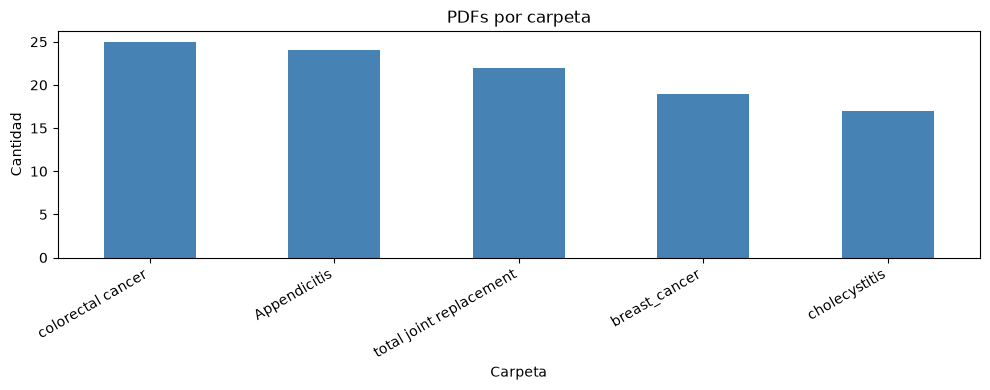

Total documentos: 107 | Total páginas: 2,098


In [4]:
folder_counts = df["folder"].value_counts().sort_values(ascending=False)
folder_counts.to_frame("n_pdfs")

fig, ax = plt.subplots(figsize=(10, 4))
folder_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("PDFs por carpeta")
ax.set_xlabel("Carpeta")
ax.set_ylabel("Cantidad")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"Total documentos: {len(df)} | Total páginas: {df['total_pages'].sum():,}")

In [5]:
top_folder = folder_counts.index[0]
share_top = folder_counts.iloc[0] / len(df) * 100
print("### Análisis — distribución por carpeta")
print(
    f"- Hay {len(folder_counts)} carpetas con {len(df)} PDFs.\n"
    f"- La más grande es **{top_folder}** ({folder_counts.iloc[0]} docs, {share_top:.1f}%).\n"
    f"- La más pequeña es **{folder_counts.index[-1]}** ({folder_counts.iloc[-1]} docs).\n"
    f"- Ratio max/min: {folder_counts.iloc[0] / folder_counts.iloc[-1]:.1f}x."
)
if "breast_cancer" in folder_counts.index:
    print("- ⚠️ Existe carpeta legacy **breast_cancer**; revisar sección 4.")

### Análisis — distribución por carpeta
- Hay 5 carpetas con 107 PDFs.
- La más grande es **colorectal cancer** (25 docs, 23.4%).
- La más pequeña es **cholecystitis** (17 docs).
- Ratio max/min: 1.5x.
- ⚠️ Existe carpeta legacy **breast_cancer**; revisar sección 4.


## 3. Idioma y longitud por carpeta


In [6]:
pd.crosstab(df["folder"], df["language"])

language,en,es,unknown
folder,,,
Appendicitis,15,8,1
breast_cancer,10,9,0
cholecystitis,10,7,0
colorectal cancer,16,9,0
total joint replacement,10,12,0


In [7]:
summary_cols = ["total_pages", "char_count", "token_count", "chars_per_page", "tokens_per_page"]
df.groupby("folder")[summary_cols].agg(["mean", "median"]).round(1)

total_pages        char_count          token_count  \
                               mean median       mean   median        mean   
folder                                                                       
Appendicitis                   13.4    8.5    35951.7  31990.0      8800.9   
breast_cancer                  23.2   14.0    62675.7  43196.0     15735.8   
cholecystitis                  18.5    8.0    41193.5  31263.0      9983.2   
colorectal cancer              24.8   10.0    69285.7  42658.0     17482.2   
total joint replacement        18.3   10.5    44994.8  42163.5     11039.2   

                                 chars_per_page         tokens_per_page  \
                          median           mean  median            mean   
folder                                                                    
Appendicitis              7565.5         3513.9  3638.8           842.7   
breast_cancer            10003.0         3353.0  3209.5           837.0   
cholecystitis             8695.0         3364.3  3580.4           826.5   
colorectal cancer        10940.0         3653.0  3788.6           913.0   
total joint replacement   9963.0         3509.5  3945.6           853.0   

                                 
                         median  
folder                           
Appendicitis              820.2  
breast_cancer             792.8  
cholecystitis             869.5  
colorectal cancer        1063.9  
total joint replacement   997.0

In [8]:
dominant_lang = df["language"].value_counts().idxmax()
lang_pct = df["language"].value_counts(normalize=True).mul(100).round(1)
longest = df.loc[df["char_count"].idxmax()]
shortest = df.loc[df["char_count"].idxmin()]
print("### Análisis — idioma y longitud")
print("- Idioma (%):", lang_pct.to_dict())
print(f"- Predominante: **{dominant_lang}**.")
print(f"- Más extenso: `{longest['file_name']}` ({int(longest['char_count']):,} chars).")
print(f"- Más corto: `{shortest['file_name']}` ({int(shortest['char_count']):,} chars).")
avg_chars = df["char_count"].mean()
avg_tokens = df["tokens_per_page"].mean()
print(f"- Promedio: {avg_chars:,.0f} chars/doc, {avg_tokens:,.0f} tokens/pág.")

### Análisis — idioma y longitud
- Idioma (%): {'en': 57.0, 'es': 42.1, 'unknown': 0.9}
- Predominante: **en**.
- Más extenso: `GUÍA DE MANEJO PARA EL DIAGNÓSTICO, TRATAMIENTO, SEGUIMIENTO Y PALIACIÓN DEL CÁNCER DE COLON Y RECTO.pdf` (667,064 chars).
- Más corto: `REVISIÓN DE LA LITERATURA SOBRE LAAPENDICITIS AGUDA PEDIATRICA NO ESPECIFICADA EN EL PERI000 2000-2021.pdf` (0 chars).
- Promedio: 51,178 chars/doc, 858 tokens/pág.


## 4. Páginas sin texto y documentos escaneados

Heurística: página con imágenes y <80 chars extraíbles = posible escaneo sin OCR.


Bajo mínimo ingest (200 chars): 1
Con ≥1 página vacía: 11
Con señal de escaneo: 12


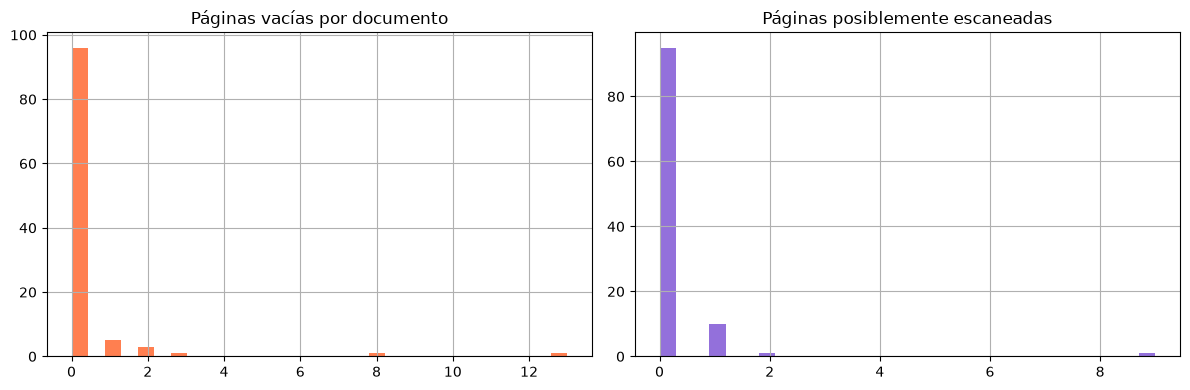

In [ ]:
print(f"Bajo mínimo ingest ({MIN_DOCUMENT_CHARS} chars): {df['below_min_chars'].sum()}")
empty_docs = (df["empty_pages"] > 0).sum()
scan_docs = (df["scanned_pages"] > 0).sum()
print(f"Con ≥1 página vacía: {empty_docs}")
print(f"Con señal de escaneo: {scan_docs}")

scan_heavy = df[df["scanned_pages"] > 0].sort_values("scanned_pages", ascending=False)
if not scan_heavy.empty:
    scan_heavy[
        ["folder", "file_name", "total_pages", "scanned_pages", "empty_pages", "char_count"]
    ].head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["empty_pages"].hist(bins=30, ax=axes[0], color="coral")
axes[0].set_title("Páginas vacías por documento")
df["scanned_pages"].hist(bins=30, ax=axes[1], color="mediumpurple")
axes[1].set_title("Páginas posiblemente escaneadas")
plt.tight_layout()
plt.show()

In [ ]:
print("### Análisis — calidad de extracción")
print(f"- {empty_docs} docs con páginas vacías (portadas, figuras, blanks).")
print(f"- {scan_docs} docs con señal de escaneo; sin OCR el RAG pierde contenido.")
if not scan_heavy.empty:
    row = scan_heavy.iloc[0]
    scanned = int(row["scanned_pages"])
    total = int(row["total_pages"])
    print(f"- Caso crítico: `{row['file_name']}` ({scanned}/{total} págs).")
if df["below_min_chars"].any():
    print("- ⚠️ Hay docs bajo umbral de ingest.")
else:
    print("- ✓ Todos superan el mínimo de caracteres para ingest.")

### Análisis — calidad de extracción
- 11 docs con páginas vacías (portadas, figuras, blanks).
- 12 docs con señal de escaneo; sin OCR el RAG pierde contenido.
- Caso crítico: `Diagnóstico y tratamiento del paciente con colecistitis aguda calculosa en el Hospital Universitario Nacional de Colombia .pdf` (9/110 págs).
- ⚠️ Hay docs bajo umbral de ingest.


## 5. Tópicos detectados vs carpeta asignada


In [ ]:
topic_matrix = pd.crosstab(df["folder"], df["detected_topic"])
display(topic_matrix)

misclassified = df[df["likely_misclassified"]].copy()
print(f"\nMisclasificados por contenido: {len(misclassified)}")
if not misclassified.empty:
    misclassified["expected_label"] = misclassified["expected_topic"].map(EXPECTED_LABELS)
    misclassified["detected_label"] = misclassified["detected_topic"].map(EXPECTED_LABELS)
    misclassified[["folder", "file_name", "expected_label", "detected_label", "topic_score"]]

legacy = df[df["folder_name_legacy"]]
print(f"\nCarpeta legacy breast_cancer: {len(legacy)} PDFs")
print(
    f"  → detectados como cervical_cancer: {(legacy['detected_topic'] == 'cervical_cancer').sum()}"
)


Misclasificados por contenido: 5

Carpeta legacy breast_cancer: 19 PDFs
  → detectados como cervical_cancer: 18


In [ ]:
print("### Análisis — coherencia carpeta vs tópico")
if misclassified.empty:
    print("- No hay conflictos fuertes entre carpeta y keywords del contenido.")
else:
    for _, row in misclassified.iterrows():
        detected = row.get("detected_label", row["detected_topic"])
        print(f"- ⚠️ `{row['file_name']}` en **{row['folder']}** → " f"sugiere **{detected}**.")
if len(legacy):
    n = (legacy["detected_topic"] == "cervical_cancer").sum()
    print(
        f"- **breast_cancer** tiene {n}/{len(legacy)} docs de cuello uterino → renombrar carpeta."
    )
for folder in topic_matrix.index:
    expected = FOLDER_TO_TOPIC.get(folder, "other")
    if expected in topic_matrix.columns:
        own = topic_matrix.loc[folder, expected]
        total = topic_matrix.loc[folder].sum()
        print(f"- {folder}: {own}/{total} alineados ({own/total*100:.0f}%).")

### Análisis — coherencia carpeta vs tópico
- ⚠️ `Establishing the need for clinical follow-up after emergency appendicectomy in the modern era_ Retrospective case series of 145 patients.pdf` en **Appendicitis** → sugiere **Otro (sin categoría)**.
- ⚠️ `REVISIÓN DE LA LITERATURA SOBRE LAAPENDICITIS AGUDA PEDIATRICA NO ESPECIFICADA EN EL PERI000 2000-2021.pdf` en **Appendicitis** → sugiere **Otro (sin categoría)**.
- ⚠️ `cervical-es-patient.pdf` en **breast_cancer** → sugiere **Otro (sin categoría)**.
- ⚠️ `CUIDADO ESTANDARIZADO EN EL PACIENTE QUIRURGICO CON ALTERACIONES EN LA FUNCION GASTROINTESTINAL.pdf` en **cholecystitis** → sugiere **Otro (sin categoría)**.
- ⚠️ `Postoperative care for patients undergoing cholecystectomy- A comprehensive nursing review.pdf` en **cholecystitis** → sugiere **Otro (sin categoría)**.
- **breast_cancer** tiene 18/19 docs de cuello uterino → renombrar carpeta.
- Appendicitis: 22/24 alineados (92%).
- breast_cancer: 18/19 alineados (95%).
- cholecystitis:

## 6. Estadísticas de tokens (embedding model)


=== Global ===
Promedio tokens/doc:  12709
Mediana tokens/doc:   9382
Promedio tokens/pág:  858
Total tokens corpus:  1,359,834

Chunks estimados (size=512, overlap=64): 3,071


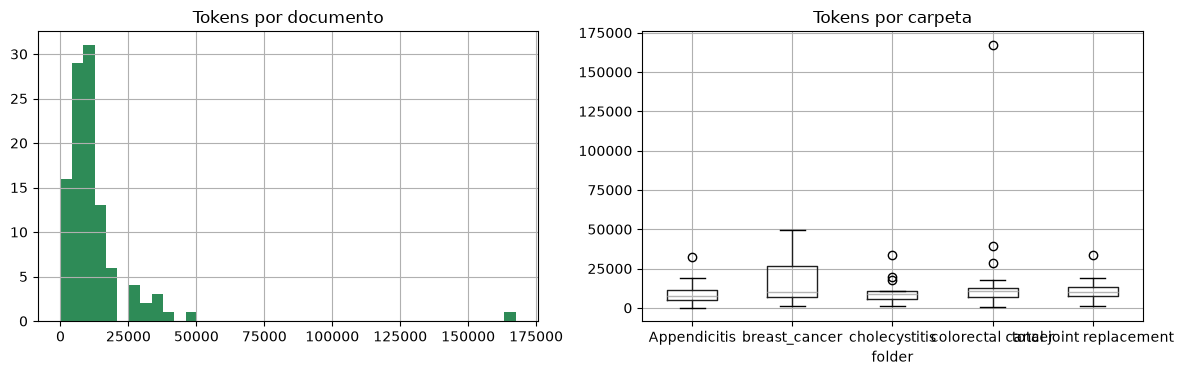

In [ ]:
print("=== Global ===")
print(f"Promedio tokens/doc:  {df['token_count'].mean():.0f}")
print(f"Mediana tokens/doc:   {df['token_count'].median():.0f}")
print(f"Promedio tokens/pág:  {df['tokens_per_page'].mean():.0f}")
print(f"Total tokens corpus:  {df['token_count'].sum():,}")

chunk_size = settings.chunk_size_tokens
overlap = settings.chunk_overlap_tokens
step = max(chunk_size - overlap, 1)
est_chunks = df["token_count"].apply(
    lambda n: max(1, (max(n - overlap, 0) + step - 1) // step) if n > 0 else 0
)
print(f"\nChunks estimados (size={chunk_size}, overlap={overlap}): {est_chunks.sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["token_count"].hist(bins=40, ax=axes[0], color="seagreen")
axes[0].set_title("Tokens por documento")
df.boxplot(column="token_count", by="folder", ax=axes[1])
axes[1].set_title("Tokens por carpeta")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
p90 = df["token_count"].quantile(0.9)
heavy = df[df["token_count"] > p90].sort_values("token_count", ascending=False)
print("### Análisis — tokens")
median_tok = df["token_count"].median()
total_tok = df["token_count"].sum()
print(f"- Mediana ~{median_tok:,.0f} tokens/doc; corpus ~{total_tok:,.0f} tokens.")
print(f"- Chunks estimados: ~{est_chunks.sum():,.0f}.")
print(f"- P90 = {p90:,.0f} tokens; {len(heavy)} docs lo superan.")
if not heavy.empty:
    heavy_name = heavy.iloc[0]["file_name"]
    heavy_count = int(heavy.iloc[0]["token_count"])
    print(f"- Más pesado: `{heavy_name}` ({heavy_count:,} tokens).")

### Análisis — tokens
- Mediana ~9,382 tokens/doc; corpus ~1,359,834 tokens.
- Chunks estimados: ~3,071.
- P90 = 26,352 tokens; 11 docs lo superan.
- Más pesado: `GUÍA DE MANEJO PARA EL DIAGNÓSTICO, TRATAMIENTO, SEGUIMIENTO Y PALIACIÓN DEL CÁNCER DE COLON Y RECTO.pdf` (167,454 tokens).


## 7. Evaluación de texto basura

Métricas de ruido en extracción PDF:
- **alpha_ratio**: letras / total chars (bajo → símbolos/ruido)
- **short_token_ratio**: tokens ≤2 chars (fragmentación PDF)
- **junk_pattern_hits**: DOI, URLs, `cid:`, metadatos bibliográficos
- **repeated_char_runs**: secuencias repetidas (`---`, `....`)
- **junk_score**: 0–1 compuesto (≥0.35 moderado, ≥0.50 alto)



Nivel de ruido por carpeta:

Documentos con junk_score ≥ 0.35: 49


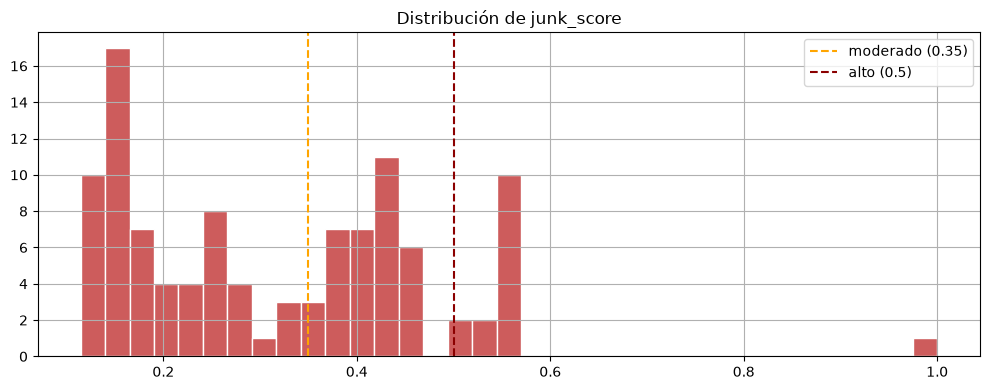

In [ ]:
JUNK_WARN = 0.35
JUNK_HIGH = 0.50

df[
    ["junk_score", "alpha_ratio", "short_token_ratio", "junk_pattern_hits", "repeated_char_runs"]
].describe().round(3)

df["junk_level"] = pd.cut(
    df["junk_score"],
    bins=[-0.001, 0.20, JUNK_WARN, JUNK_HIGH, 1.0],
    labels=["limpio", "leve", "moderado", "alto"],
)
print("\nNivel de ruido por carpeta:")
pd.crosstab(df["folder"], df["junk_level"])

suspects = df[df["junk_score"] >= JUNK_WARN].sort_values("junk_score", ascending=False)
print(f"\nDocumentos con junk_score ≥ {JUNK_WARN}: {len(suspects)}")
if not suspects.empty:
    suspects[
        [
            "folder",
            "file_name",
            "junk_score",
            "alpha_ratio",
            "short_token_ratio",
            "junk_pattern_hits",
        ]
    ].head(12)

fig, ax = plt.subplots(figsize=(10, 4))
df["junk_score"].hist(bins=35, ax=ax, color="indianred", edgecolor="white")
ax.axvline(JUNK_WARN, color="orange", linestyle="--", label=f"moderado ({JUNK_WARN})")
ax.axvline(JUNK_HIGH, color="darkred", linestyle="--", label=f"alto ({JUNK_HIGH})")
ax.set_title("Distribución de junk_score")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
print("### Análisis — texto basura")
clean = (df["junk_score"] < JUNK_WARN).sum()
moderate = ((df["junk_score"] >= JUNK_WARN) & (df["junk_score"] < JUNK_HIGH)).sum()
high = (df["junk_score"] >= JUNK_HIGH).sum()
print(f"- {clean} docs ({clean/len(df)*100:.0f}%) limpios (junk_score < {JUNK_WARN}).")
print(f"- {moderate} docs ({moderate/len(df)*100:.0f}%) ruido moderado.")
print(f"- {high} docs ({high/len(df)*100:.0f}%) ruido alto → revisar OCR/limpieza.")
if not suspects.empty:
    worst = suspects.iloc[0]
    worst_name = worst["file_name"]
    worst_score = worst["junk_score"]
    worst_alpha = worst["alpha_ratio"]
    print(f"- Peor caso: `{worst_name}` " f"(score={worst_score:.2f}, alpha={worst_alpha:.2f}).")
    print(f"  Extracto: {worst['excerpt'][:250]}…")
avg_alpha = df["alpha_ratio"].mean()
print(f"- alpha_ratio promedio: {avg_alpha:.2f} (ideal > 0.70).")
if avg_alpha < 0.65:
    print("- ⚠️ Mucho ruido no alfabético; revisar pipeline antes del chunking.")

### Análisis — texto basura
- 58 docs (54%) limpios (junk_score < 0.35).
- 34 docs (32%) ruido moderado.
- 15 docs (14%) ruido alto → revisar OCR/limpieza.
- Peor caso: `REVISIÓN DE LA LITERATURA SOBRE LAAPENDICITIS AGUDA PEDIATRICA NO ESPECIFICADA EN EL PERI000 2000-2021.pdf` (score=1.00, alpha=0.00).
  Extracto: …
- alpha_ratio promedio: 0.76 (ideal > 0.70).


## 8. Resumen ejecutivo


In [17]:
breast_folder = df[df["folder"] == "breast_cancer"]
summary = {
    "total_pdfs": len(df),
    "total_pages": int(df["total_pages"].sum()),
    "avg_tokens_per_doc": round(df["token_count"].mean(), 1),
    "docs_misclassified": int(df["likely_misclassified"].sum()),
    "docs_scanned_signal": int((df["scanned_pages"] > 0).sum()),
    "docs_high_junk": int((df["junk_score"] >= JUNK_HIGH).sum()),
    "breast_folder_as_cervical": int((breast_folder["detected_topic"] == "cervical_cancer").sum()),
    "duplicate_file_name_groups": len(dup_names),
    "duplicate_content_groups": len(dup_hashes),
    "unique_content_hashes": int(df["content_hash"].nunique()),
    "est_chunks": int(est_chunks.sum()),
}
pd.Series(summary).to_frame("valor")

,valor
total_pdfs,107.0
total_pages,2098.0
avg_tokens_per_doc,12708.7
docs_misclassified,5.0
docs_scanned_signal,12.0
docs_high_junk,15.0
breast_folder_as_cervical,18.0
est_chunks,3071.0


In [18]:
print("### Análisis — resumen ejecutivo")
print(
    f"Corpus: **{summary['total_pdfs']} PDFs** / **{summary['total_pages']:,} págs** "
    f"→ ~**{summary['est_chunks']:,} chunks** estimados."
)
actions: list[str] = []
if summary["docs_misclassified"]:
    actions.append(f"reclasificar {summary['docs_misclassified']} PDF(s)")
if summary["breast_folder_as_cervical"]:
    actions.append("renombrar breast_cancer → cuello uterino")
if summary["docs_scanned_signal"]:
    actions.append(f"OCR en {summary['docs_scanned_signal']} doc(s) escaneados")
if summary["docs_high_junk"]:
    actions.append(f"limpiar {summary['docs_high_junk']} doc(s) con alto junk_score")
if summary["duplicate_file_name_groups"]:
    actions.append(
        f"revisar {summary['duplicate_file_name_groups']} grupo(s) con nombres duplicados"
    )
if summary["duplicate_content_groups"]:
    actions.append(
        f"eliminar {summary['duplicate_content_groups']} grupo(s) de contenido duplicado"
    )
print("Acciones:" + ("; ".join(actions) + "." if actions else " ninguna crítica detectada."))

### Análisis — resumen ejecutivo
Corpus: **107 PDFs** / **2,098 págs** → ~**3,071 chunks** estimados.
Acciones:reclasificar 5 PDF(s); renombrar breast_cancer → cuello uterino; OCR en 12 doc(s) escaneados; limpiar 15 doc(s) con alto junk_score.
